<a href="https://colab.research.google.com/github/avishi0229/herpes_zoster_btp/blob/main/image_model_btp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Branch: ResNet50 for Herpes Zoster (HZ) Detection
**BTP: A Multimodal Explainable AI Framework for Herpes Zoster Detection**

Image-only baseline → image embedding (for later fusion) → Grad-CAM.
Research / decision-support prototype only. **Not a clinical diagnosis tool.**

Rules followed: existing case-level split is used as-is; augmentation only on train; test set is used once, at the end, with a fixed 0.5 threshold.

## 1. Check environment and GPU

In [ ]:
import torch
print('PyTorch', torch.__version__)
print('GPU available:', torch.cuda.is_available())
if torch.cuda.is_available(): print(torch.cuda.get_device_name(0))
else: print('-> Runtime > Change runtime type > T4 GPU')

PyTorch 2.11.0+cu128
GPU available: True
Tesla T4


## 2. Imports, config, seeds (reproducibility)

In [ ]:
import json, random, copy, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay)

SEED = 42
def set_seed(s=SEED):
    os.environ['PYTHONHASHSEED'] = str(s)
    random.seed(s); np.random.seed(s)                          # Python + NumPy
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)        # PyTorch (CPU + GPU)
    torch.backends.cudnn.deterministic = True                  # avoid nondeterministic conv kernels
    torch.backends.cudnn.benchmark = False
set_seed()
print('Random seed in use:', SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
REPO = "."
IMG_DIR = f"{REPO}/data/images"
OUT = f"{REPO}/outputs/image"         # everything we save goes here
for d in ['', '/plots', '/embeddings', '/gradcam', '/gradcam/correct_hz', '/gradcam/incorrect_hz',
          '/gradcam/correct_non_hz', '/gradcam/incorrect_non_hz']: os.makedirs(OUT + d, exist_ok=True)

IMG_SIZE, BATCH = 224, 16
print('Device:', DEVICE)

Random seed in use: 42
Device: cuda


## 3. Inspect CSV columns (no assumptions)

In [ ]:
splits_raw = {s: pd.read_csv(f'{REPO}/data/processed/{s}.csv') for s in ['train', 'validation', 'test']}
for s, d in splits_raw.items():
    print(s, d.shape, '| labels:', d['label'].value_counts().to_dict())
print('\nColumns:', list(splits_raw['train'].columns))
splits_raw['train'][['case_id','label','condition','image_1_path','image_2_path','image_3_path','num_images']].head()

train (78, 31) | labels: {1: 39, 0: 39}
validation (17, 31) | labels: {1: 9, 0: 8}
test (17, 31) | labels: {0: 9, 1: 8}

Columns: ['case_id', 'label', 'condition', 'age_group', 'sex_at_birth', 'fitzpatrick_skin_type', 'textures_raised_or_bumpy', 'textures_flat', 'textures_rough_or_flaky', 'textures_fluid_filled', 'body_parts_head_or_neck', 'body_parts_arm', 'body_parts_palm', 'body_parts_back_of_hand', 'body_parts_torso_front', 'body_parts_torso_back', 'body_parts_buttocks', 'body_parts_leg', 'body_parts_foot_top_or_side', 'body_parts_foot_sole', 'condition_symptoms_itching', 'condition_symptoms_burning', 'condition_symptoms_pain', 'other_symptoms_fever', 'other_symptoms_chills', 'other_symptoms_fatigue', 'condition_duration', 'image_1_path', 'image_2_path', 'image_3_path', 'num_images']


,case_id,label,condition,image_1_path,image_2_path,image_3_path,num_images
0,-2956980661052614661,1,Herpes Zoster,dataset/images/-1851106847572018342.png,NaN,NaN,1.0
1,588529798435401035,1,Herpes Zoster,dataset/images/-1401905848534862361.png,dataset/images/4412316929119123118.png,NaN,2.0
2,-1542593210179870498,0,Impetigo,dataset/images/5904657460937594916.png,NaN,NaN,NaN
3,9097048639908724577,0,Urticaria,dataset/images/-6272728721081099136.png,NaN,NaN,NaN
4,8773806236538349731,1,Herpes Zoster,dataset/images/2218786370631568755.png,NaN,NaN,1.0


**Finding:** each CSV row is a *case* with up to 3 image columns (`image_1_path`…`image_3_path`) and label column `label` (1 = HZ). Paths inside the CSV start with `dataset/images/`, but the repo folder is `data/images/`, so we resolve by **filename only**. Below we expand to one row per image while keeping `case_id`.

In [ ]:
IMG_COLS = [c for c in splits_raw['train'].columns if c.startswith('image_') and c.endswith('_path')]

def to_image_level(df):
    rows = []
    for _, r in df.iterrows():
        for c in IMG_COLS:
            if pd.notna(r[c]):
                rows.append({'case_id': r['case_id'], 'label': int(r['label']),
                             'condition': r['condition'],
                             'path': os.path.join(IMG_DIR, os.path.basename(r[c]))})
    return pd.DataFrame(rows)

data = {s: to_image_level(d) for s, d in splits_raw.items()}

# verification
for s, d in data.items():
    missing = [p for p in d.path if not os.path.exists(p)]
    print(f'{s:11s} cases={d.case_id.nunique():3d} images={len(d):3d} '
          f'HZ_imgs={int((d.label==1).sum())} nonHZ_imgs={int((d.label==0).sum())} missing={len(missing)}')
    assert not missing
# leakage checks
ids = {s: set(d.case_id) for s, d in data.items()}
assert not (ids['train'] & ids['validation']) and not (ids['train'] & ids['test']) and not (ids['validation'] & ids['test'])
imgs = {s: set(d.path) for s, d in data.items()}
assert not (imgs['train'] & imgs['validation']) and not (imgs['train'] & imgs['test']) and not (imgs['validation'] & imgs['test'])
print('No case / image overlap between splits. All image files exist.')

train       cases= 78 images=155 HZ_imgs=73 nonHZ_imgs=82 missing=0
validation  cases= 17 images= 35 HZ_imgs=22 nonHZ_imgs=13 missing=0
test        cases= 17 images= 33 HZ_imgs=14 nonHZ_imgs=19 missing=0
No case / image overlap between splits. All image files exist.


## 4. Sample images

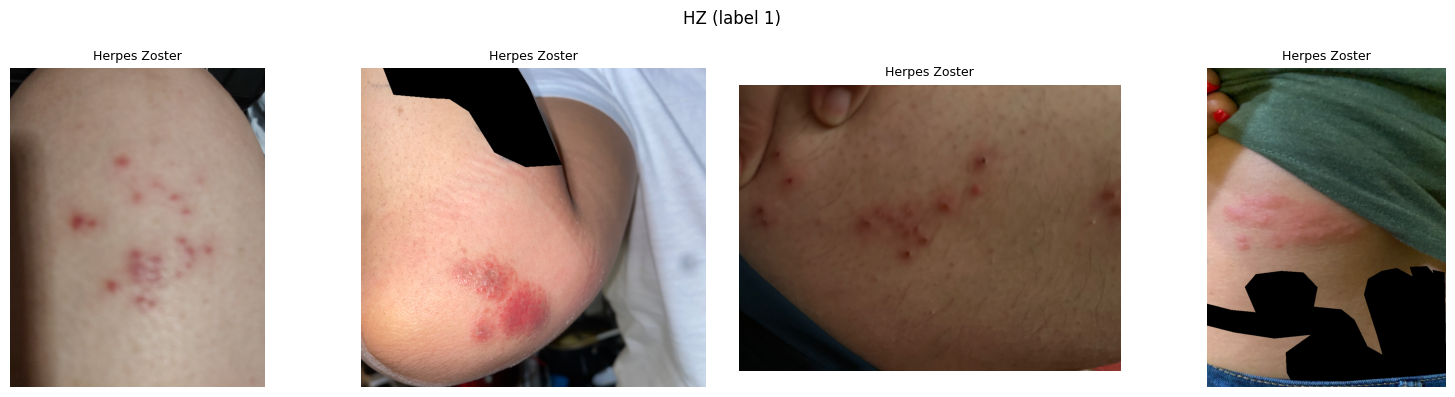

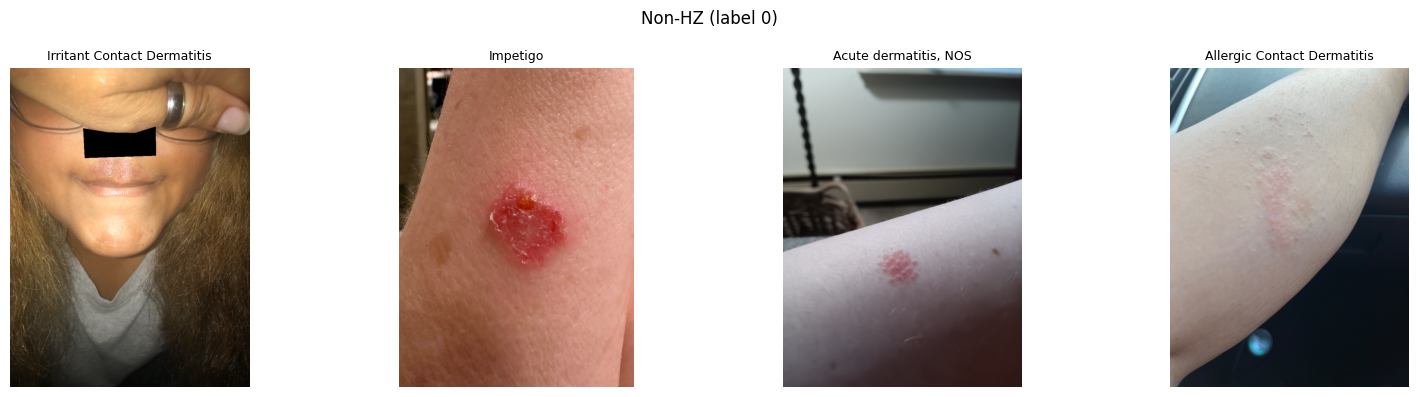

In [ ]:
def show_samples(df, label, n=4, title=''):
    sub = df[df.label == label].sample(n, random_state=SEED)
    fig, ax = plt.subplots(1, n, figsize=(4*n, 4))
    for a, (_, r) in zip(ax, sub.iterrows()):
        a.imshow(Image.open(r.path).convert('RGB')); a.set_title(f'{r.condition}', fontsize=9); a.axis('off')
    fig.suptitle(title); plt.tight_layout(); plt.show()
show_samples(data['train'], 1, title='HZ (label 1)')
show_samples(data['train'], 0, title='Non-HZ (label 0)')

## 5. Preprocessing, augmentation (train only), Dataset & DataLoader
ImageNet normalisation (needed for pretrained ResNet50). Augmentation is mild, since lesion colour/texture matters.

In [ ]:
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD)])
eval_tf = transforms.Compose([                      # NO augmentation for val/test
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

class SkinDataset(Dataset):
    def __init__(self, df, tf): self.df, self.tf = df.reset_index(drop=True), tf
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        x = self.tf(Image.open(r.path).convert('RGB'))
        return x, torch.tensor(r.label, dtype=torch.float32), r.case_id, r.path

def _seed_worker(worker_id):
    np.random.seed(SEED + worker_id); random.seed(SEED + worker_id)

def make_loader(split, tf, shuffle):
    g = torch.Generator(); g.manual_seed(SEED)                 # reproducible shuffling / augmentation
    return DataLoader(SkinDataset(data[split], tf), batch_size=BATCH, shuffle=shuffle,
                      num_workers=2, worker_init_fn=_seed_worker, generator=g)

train_loader = make_loader('train', train_tf, True)
val_loader   = make_loader('validation', eval_tf, False)
test_loader  = make_loader('test', eval_tf, False)
print(len(train_loader.dataset), len(val_loader.dataset), len(test_loader.dataset))

155 35 33


## 6. Model: ResNet50 with an accessible embedding
`backbone` outputs the 2048-d image embedding (`get_embedding`); `classifier` maps it to one HZ logit. The fusion model can later reuse `backbone` directly.

In [ ]:
class HZImageModel(nn.Module):
    def __init__(self, dropout=0.5):
        super().__init__()
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.emb_dim = self.backbone.fc.in_features      # 2048
        self.backbone.fc = nn.Identity()                  # output = image embedding
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(self.emb_dim, 1))
    def get_embedding(self, x): return self.backbone(x)   # (B, 2048)
    def forward(self, x): return self.classifier(self.get_embedding(x)).squeeze(1)  # logits

def set_trainable(model, phase):
    for p in model.parameters(): p.requires_grad = False
    for p in model.classifier.parameters(): p.requires_grad = True
    if phase == 2:                                        # fine-tune last block only
        for p in model.backbone.layer4.parameters(): p.requires_grad = True

def set_mode(model, phase):
    model.train()
    if phase == 1: model.backbone.eval()                  # keep BN stats frozen with frozen backbone
    else:
        for n, m in model.backbone.named_modules():
            if isinstance(m, nn.BatchNorm2d) and not n.startswith('layer4'): m.eval()

model = HZImageModel().to(DEVICE)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 40.3MB/s]


## 7. Training utilities

In [ ]:
criterion = nn.BCEWithLogitsLoss()

def run_epoch(model, loader, optimizer=None, phase=1):
    train = optimizer is not None
    if train: set_mode(model, phase)
    else: model.eval()
    tot_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for x, y, _, _ in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x); loss = criterion(logits, y)
            if train: optimizer.zero_grad(); loss.backward(); optimizer.step()
            tot_loss += loss.item() * len(y)
            correct += ((torch.sigmoid(logits) > 0.5).float() == y).sum().item(); n += len(y)
    return tot_loss / n, correct / n

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'phase': []}
best = {'val_loss': float('inf'), 'state': None, 'epoch': -1}
CKPT = f'{OUT}/best_resnet50.pth'

def fit(phase, epochs, lr_head, lr_backbone=None, patience=6):
    global best
    set_trainable(model, phase)
    groups = [{'params': model.classifier.parameters(), 'lr': lr_head}]
    if phase == 2: groups.append({'params': model.backbone.layer4.parameters(), 'lr': lr_backbone})
    opt = torch.optim.AdamW(groups, weight_decay=1e-2)
    bad = 0
    for ep in range(1, epochs + 1):
        tl, ta = run_epoch(model, train_loader, opt, phase)
        vl, va = run_epoch(model, val_loader)
        for k, v in zip(['train_loss','val_loss','train_acc','val_acc','phase'], [tl, vl, ta, va, phase]): history[k].append(v)
        flag = ''
        if vl < best['val_loss']:                    # model selection on VALIDATION loss only
            best.update(val_loss=vl, state=copy.deepcopy(model.state_dict()), epoch=len(history['val_loss']))
            torch.save(best['state'], CKPT); flag = ' *best*'; bad = 0
        else: bad += 1
        print(f'P{phase} ep{ep:02d} | train loss {tl:.4f} acc {ta:.3f} | val loss {vl:.4f} acc {va:.3f}{flag}')
        if bad >= patience: print('Early stopping'); break

## 8. Phase 1: train the head only (backbone frozen)

In [ ]:
fit(phase=1, epochs=20, lr_head=1e-3)

P1 ep01 | train loss 0.6928 acc 0.548 | val loss 0.6883 acc 0.571 *best*
P1 ep02 | train loss 0.6449 acc 0.671 | val loss 0.6582 acc 0.629 *best*
P1 ep03 | train loss 0.6044 acc 0.729 | val loss 0.6332 acc 0.657 *best*
P1 ep04 | train loss 0.6004 acc 0.684 | val loss 0.6003 acc 0.714 *best*
P1 ep05 | train loss 0.5553 acc 0.735 | val loss 0.5945 acc 0.714 *best*
P1 ep06 | train loss 0.5211 acc 0.768 | val loss 0.5802 acc 0.743 *best*
P1 ep07 | train loss 0.5189 acc 0.761 | val loss 0.5666 acc 0.743 *best*
P1 ep08 | train loss 0.4808 acc 0.774 | val loss 0.5609 acc 0.743 *best*
P1 ep09 | train loss 0.4894 acc 0.774 | val loss 0.5534 acc 0.771 *best*
P1 ep10 | train loss 0.4559 acc 0.819 | val loss 0.5561 acc 0.743
P1 ep11 | train loss 0.4561 acc 0.781 | val loss 0.5393 acc 0.771 *best*
P1 ep12 | train loss 0.4523 acc 0.794 | val loss 0.5372 acc 0.771 *best*
P1 ep13 | train loss 0.4348 acc 0.852 | val loss 0.5472 acc 0.743
P1 ep14 | train loss 0.4276 acc 0.845 | val loss 0.5463 acc 0.714

## 9. Phase 2 (optional): fine-tune `layer4` with a low learning rate
Starts from the best phase-1 weights. Set `FINE_TUNE = False` to skip.

In [ ]:
FINE_TUNE = True
if FINE_TUNE:
    model.load_state_dict(best['state'])
    fit(phase=2, epochs=20, lr_head=1e-4, lr_backbone=1e-5)
model.load_state_dict(torch.load(CKPT, map_location=DEVICE))
print('Best epoch (global index):', best['epoch'], '| val loss:', round(best['val_loss'], 4))

P2 ep01 | train loss 0.5169 acc 0.748 | val loss 0.6719 acc 0.543
P2 ep02 | train loss 0.5026 acc 0.761 | val loss 0.7133 acc 0.514
P2 ep03 | train loss 0.4731 acc 0.800 | val loss 0.7111 acc 0.514
P2 ep04 | train loss 0.4827 acc 0.819 | val loss 0.7128 acc 0.543
P2 ep05 | train loss 0.4596 acc 0.819 | val loss 0.7044 acc 0.543
P2 ep06 | train loss 0.4420 acc 0.858 | val loss 0.6898 acc 0.543
Early stopping
Best epoch (global index): 19 | val loss: 0.5263


## 10. Training curves

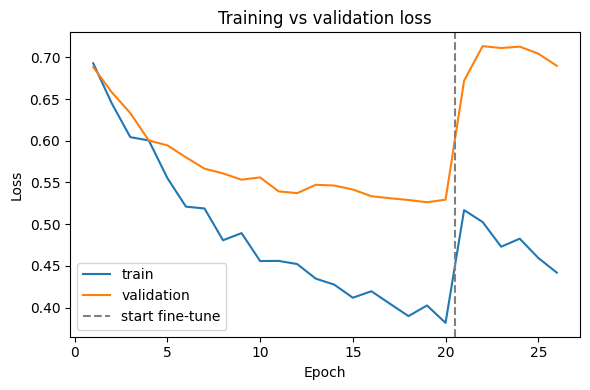

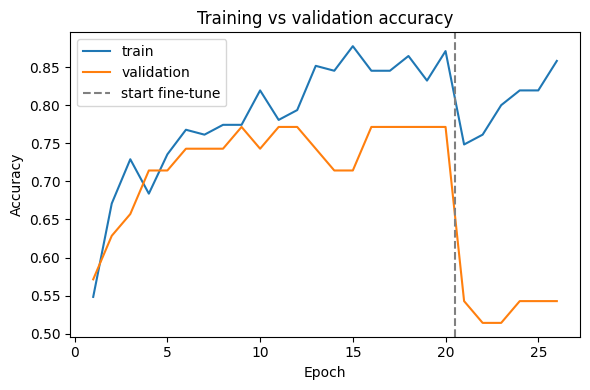

In [ ]:
ep = range(1, len(history['train_loss']) + 1)
switch = next((i for i, p in enumerate(history['phase']) if p == 2), None)
for key, name in [('loss', 'Loss'), ('acc', 'Accuracy')]:
    plt.figure(figsize=(6, 4))
    plt.plot(ep, history[f'train_{key}'], label='train'); plt.plot(ep, history[f'val_{key}'], label='validation')
    if switch is not None: plt.axvline(switch + 0.5, ls='--', c='gray', label='start fine-tune')
    plt.xlabel('Epoch'); plt.ylabel(name); plt.title(f'Training vs validation {name.lower()}'); plt.legend()
    fname = 'loss_curve.png' if key == 'loss' else 'accuracy_curve.png'
    plt.tight_layout(); plt.savefig(f'{OUT}/{fname}', dpi=150); plt.savefig(f'{OUT}/plots/{fname}', dpi=150); plt.show()
json.dump(history, open(f'{OUT}/training_history.json', 'w'), indent=2)   # per-epoch train/val loss & accuracy

## 11. Evaluation: image-level and case-level
Threshold is fixed at 0.5 (not tuned on test). Case-level = **mean HZ probability across all images of that case**.

In [ ]:
@torch.no_grad()
def predict(loader):
    model.eval(); P, Y, C, F = [], [], [], []
    for x, y, cid, path in loader:
        P += torch.sigmoid(model(x.to(DEVICE))).cpu().tolist(); Y += y.int().tolist()
        C += [int(c) for c in cid]; F += list(path)
    return pd.DataFrame({'case_id': C, 'path': F, 'y': Y, 'prob': P})

def metrics(y, p, thr=0.5):
    y = np.array(y); yhat = (np.array(p) >= thr).astype(int)
    tn, fp, fn, tp = [int(v) for v in confusion_matrix(y, yhat, labels=[0, 1]).ravel()]
    return {'accuracy': float(accuracy_score(y, yhat)),
            'precision': float(precision_score(y, yhat, zero_division=0)),
            'recall': float(recall_score(y, yhat, zero_division=0)),          # = sensitivity
            'specificity': float(tn / (tn + fp)) if (tn + fp) > 0 else float('nan'),   # TN / (TN + FP)
            'f1': float(f1_score(y, yhat, zero_division=0)),
            'roc_auc': float(roc_auc_score(y, p)) if len(set(y)) > 1 else float('nan'),
            'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp, 'n': int(len(y))}

def case_level(df):
    return df.groupby('case_id').agg(y=('y', 'first'), prob=('prob', 'mean'), n_images=('path', 'count')).reset_index()

results = {}
for name, loader in [('validation', val_loader), ('test', test_loader)]:
    img = predict(loader); cas = case_level(img)
    results[name] = {'image_level': metrics(img.y, img.prob), 'case_level': metrics(cas.y, cas.prob)}
    img.to_csv(f'{OUT}/{name}_image_predictions.csv', index=False); cas.to_csv(f'{OUT}/{name}_case_predictions.csv', index=False)
    if name == 'test': test_img, test_case = img, cas

json.dump(results, open(f'{OUT}/metrics.json', 'w'), indent=2)
print(pd.concat({f'{s}/{l}': pd.Series(m) for s, d in results.items() for l, m in d.items()}, axis=1).round(3).T)

                        accuracy  precision  recall  specificity     f1  \
validation/image_level     0.771      0.938   0.682        0.923  0.789   
validation/case_level      0.882      0.889   0.889        0.875  0.889   
test/image_level           0.697      0.600   0.857        0.579  0.706   
test/case_level            0.588      0.545   0.750        0.444  0.632   

                        roc_auc    tn   fp   fn    tp     n  
validation/image_level    0.881  12.0  1.0  7.0  15.0  35.0  
validation/case_level     0.931   7.0  1.0  1.0   8.0  17.0  
test/image_level          0.692  11.0  8.0  2.0  12.0  33.0  
test/case_level           0.639   4.0  5.0  2.0   6.0  17.0  


## 12. Confusion matrices and ROC curves (test set)

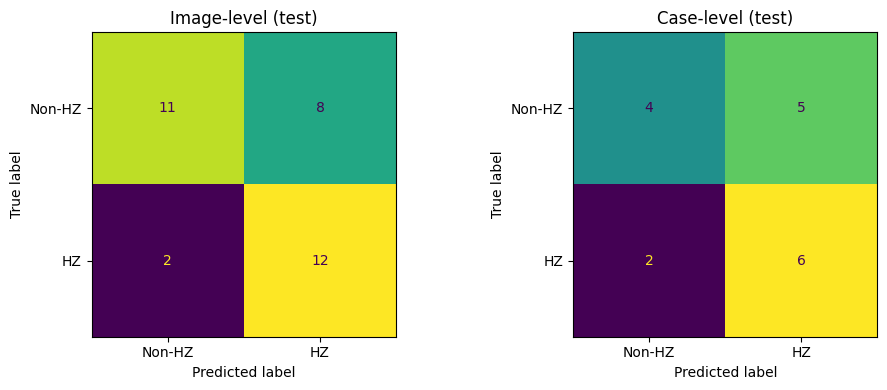

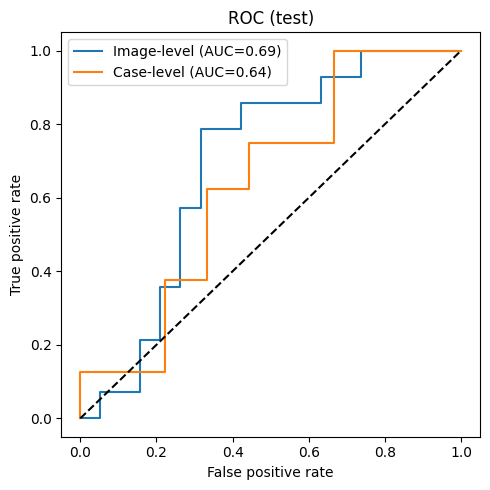

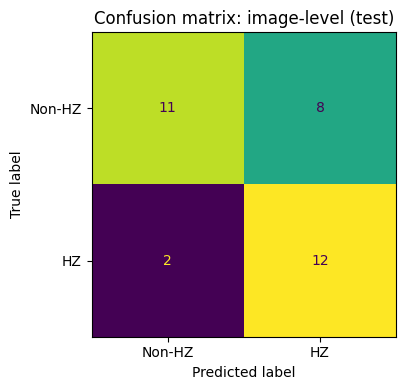

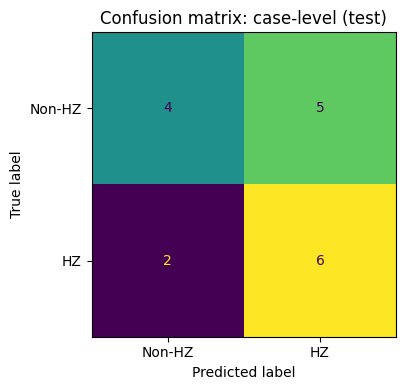

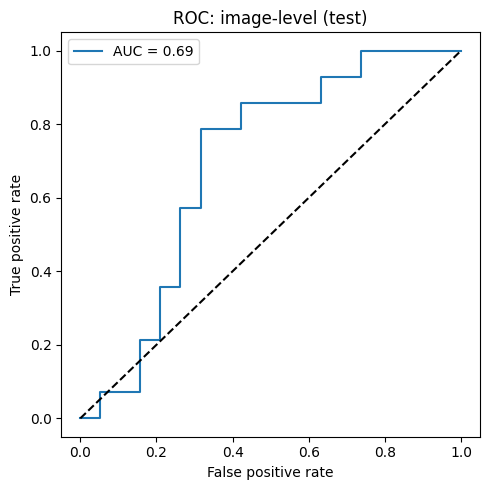

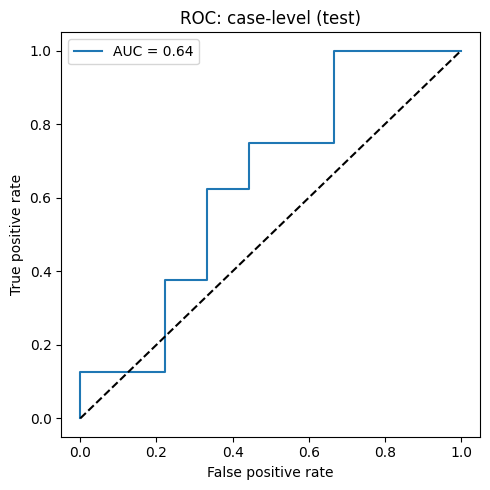

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, (df, title) in zip(ax, [(test_img, 'Image-level'), (test_case, 'Case-level')]):
    cm = confusion_matrix(df.y, (df.prob >= 0.5).astype(int), labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=['Non-HZ', 'HZ']).plot(ax=a, colorbar=False); a.set_title(f'{title} (test)')
plt.tight_layout(); plt.savefig(f'{OUT}/plots/confusion_matrices.png', dpi=150); plt.show()

plt.figure(figsize=(5, 5))
for df, lab in [(test_img, 'Image-level'), (test_case, 'Case-level')]:
    fpr, tpr, _ = roc_curve(df.y, df.prob); plt.plot(fpr, tpr, label=f'{lab} (AUC={roc_auc_score(df.y, df.prob):.2f})')
plt.plot([0, 1], [0, 1], 'k--'); plt.xlabel('False positive rate'); plt.ylabel('True positive rate')
plt.title('ROC (test)'); plt.legend(); plt.tight_layout(); plt.savefig(f'{OUT}/plots/roc_curve.png', dpi=150); plt.show()

# --- separate files with the required names (added) ---
def cm_plot(df, title, fname):
    cm = confusion_matrix(df.y, (df.prob >= 0.5).astype(int), labels=[0, 1])
    fig, a = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay(cm, display_labels=['Non-HZ', 'HZ']).plot(ax=a, colorbar=False); a.set_title(title)
    plt.tight_layout(); plt.savefig(f'{OUT}/{fname}', dpi=150); plt.show()

def roc_plot(df, title, fname):
    fpr, tpr, _ = roc_curve(df.y, df.prob)
    plt.figure(figsize=(5, 5)); plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(df.y, df.prob):.2f}'); plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False positive rate'); plt.ylabel('True positive rate'); plt.title(title); plt.legend()
    plt.tight_layout(); plt.savefig(f'{OUT}/{fname}', dpi=150); plt.show()

cm_plot(test_img,  'Confusion matrix: image-level (test)', 'confusion_matrix_image.png')
cm_plot(test_case, 'Confusion matrix: case-level (test)',  'confusion_matrix_case.png')
roc_plot(test_img,  'ROC: image-level (test)', 'roc_curve_image.png')
roc_plot(test_case, 'ROC: case-level (test)',  'roc_curve_case.png')

## 12b. Classification reports (test set)

In [ ]:
from sklearn.metrics import classification_report
for df, tag in [(test_img, 'image'), (test_case, 'case')]:
    rep_txt = classification_report(df.y, (df.prob >= 0.5).astype(int), labels=[0, 1],
                                    target_names=['Non-HZ', 'HZ'], digits=3, zero_division=0)
    text = f'Test set, {tag}-level (n={len(df)}), threshold=0.5\n\n{rep_txt}'
    open(f'{OUT}/classification_report_{tag}.txt', 'w').write(text)
    print(text)

Test set, image-level (n=33), threshold=0.5

              precision    recall  f1-score   support

      Non-HZ      0.846     0.579     0.688        19
          HZ      0.600     0.857     0.706        14

    accuracy                          0.697        33
   macro avg      0.723     0.718     0.697        33
weighted avg      0.742     0.697     0.695        33

Test set, case-level (n=17), threshold=0.5

              precision    recall  f1-score   support

      Non-HZ      0.667     0.444     0.533         9
          HZ      0.545     0.750     0.632         8

    accuracy                          0.588        17
   macro avg      0.606     0.597     0.582        17
weighted avg      0.610     0.588     0.580        17



## 13. Image embedding interface + saving embeddings for the fusion model
`get_image_embedding(model, dataloader)` returns `case_id`, `image_path`, and the 2048-d `embedding` taken **before** the final classification layer (plus true label and probability for convenience).
Saved per split: `outputs/image/{train,validation,test}_embeddings.csv` (one row per image) and `outputs/image/embeddings/{split}_case_embeddings.csv` (one row per case = mean over that case's images, which is what you join with the clinical embedding on `case_id`).
Embeddings use the eval transform (no augmentation) for all splits.

In [ ]:

@torch.no_grad()
def get_image_embedding(model, dataloader):
    """Returns dict with case_id, image_path, embedding (N x 2048, BEFORE the classifier), label, prob."""
    model.eval()
    ids, paths, embs, ys, probs = [], [], [], [], []
    for x, y, cid, path in dataloader:
        e = model.get_embedding(x.to(DEVICE))                        # 2048-d, pre-classifier
        p = torch.sigmoid(model.classifier(e).squeeze(1))            # same output as model(x)
        embs.append(e.cpu().numpy()); probs += p.cpu().tolist()
        ids += [int(c) for c in cid]; paths += list(path); ys += y.int().tolist()
    return {'case_id': ids, 'image_path': paths, 'embedding': np.concatenate(embs),
            'label': np.array(ys), 'prob': np.array(probs)}

def save_embeddings(split):
    o = get_image_embedding(model, make_loader(split, eval_tf, False))
    emb = o['embedding']; assert emb.shape[1] == 2048, emb.shape
    meta = pd.DataFrame({'case_id': o['case_id'],
                         'image_path': [os.path.relpath(p, REPO) for p in o['image_path']],
                         'true_label': o['label'], 'pred_prob': o['prob'],
                         'pred_label': (o['prob'] >= 0.5).astype(int)})
    df = pd.concat([meta, pd.DataFrame(emb, columns=[f'emb_{i}' for i in range(emb.shape[1])])], axis=1)
    df.to_csv(f'{OUT}/{split}_embeddings.csv', index=False)
    feat = [c for c in df.columns if c.startswith('emb_')]
    case = df.groupby('case_id').agg({'true_label': 'first', 'pred_prob': 'mean', **{c: 'mean' for c in feat}}).reset_index()
    case.to_csv(f'{OUT}/embeddings/{split}_case_embeddings.csv', index=False)
    chk = pd.read_csv(f'{OUT}/{split}_embeddings.csv')                 # reload check
    assert chk.shape == (len(data[split]), 5 + 2048) and chk.case_id.nunique() == data[split].case_id.nunique()
    print(f'{split:11s} image rows={df.shape[0]:3d}  case rows={case.shape[0]:3d}  embedding dim={emb.shape[1]}')

for s in ['train', 'validation', 'test']:
    save_embeddings(s)


train       image rows=155  case rows= 78  embedding dim=2048
validation  image rows= 35  case rows= 17  embedding dim=2048
test        image rows= 33  case rows= 17  embedding dim=2048


## 14. Grad-CAM: qualitative examples (TEST set only, final model)
Uses the last ResNet50 block (`layer4[-1]`) and the **HZ logit**, so heatmaps show regions pushing the prediction toward HZ. Categories (image-level, threshold 0.5):
- `correct_hz`: true HZ, predicted HZ
- `incorrect_hz`: true HZ, predicted Non-HZ (false negative)
- `correct_non_hz`: true Non-HZ, predicted Non-HZ
- `incorrect_non_hz`: true Non-HZ, predicted HZ (false positive)

Representative examples = the highest-confidence predictions in each category (deterministic, no cherry-picking). Heatmaps are a visual aid and do not prove the model uses clinically meaningful features.

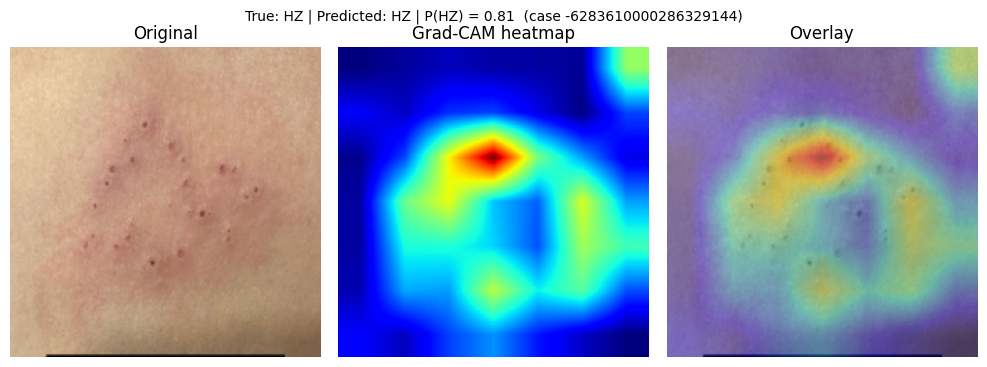

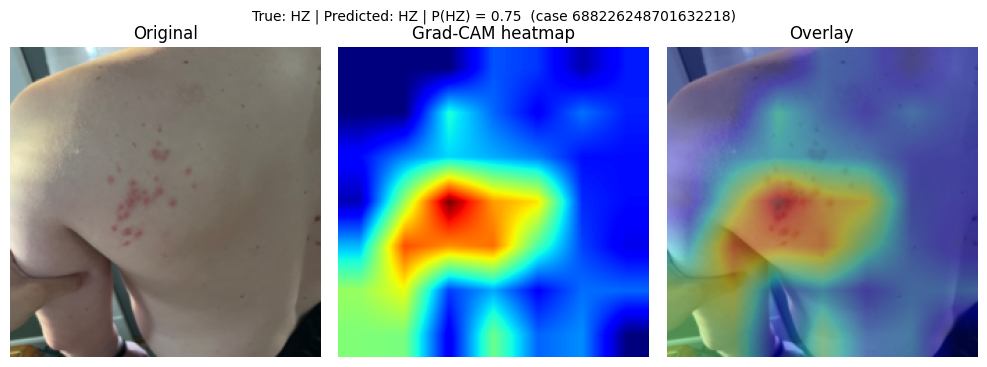

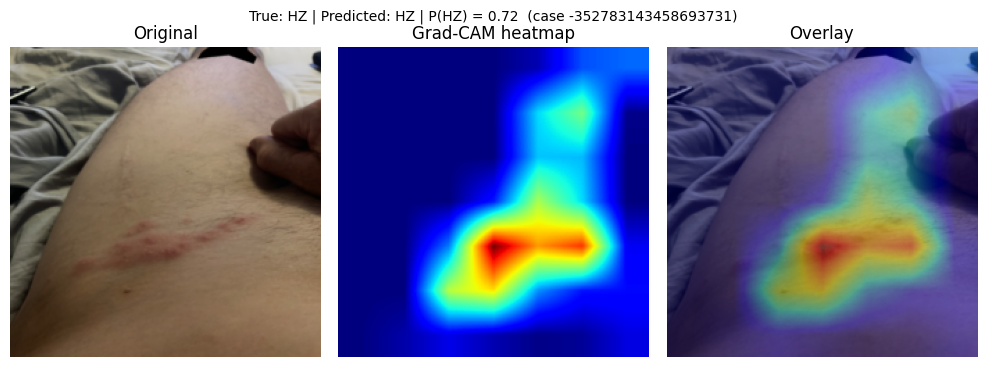

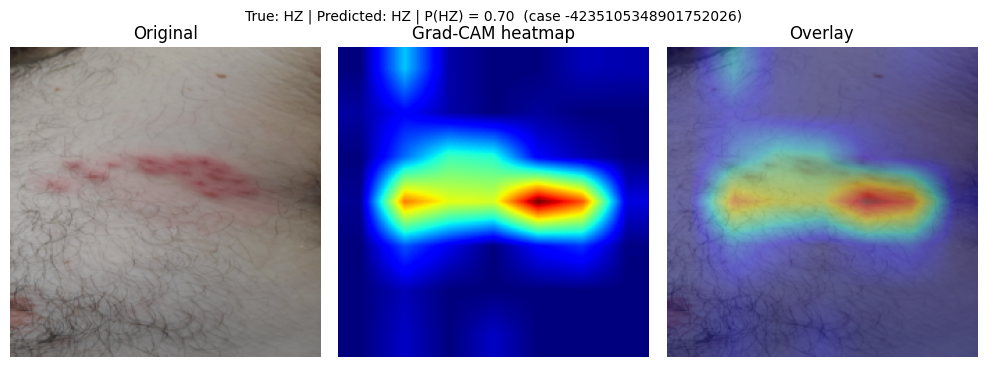

[correct_hz] saved 4 example(s) (12 available in the test set)


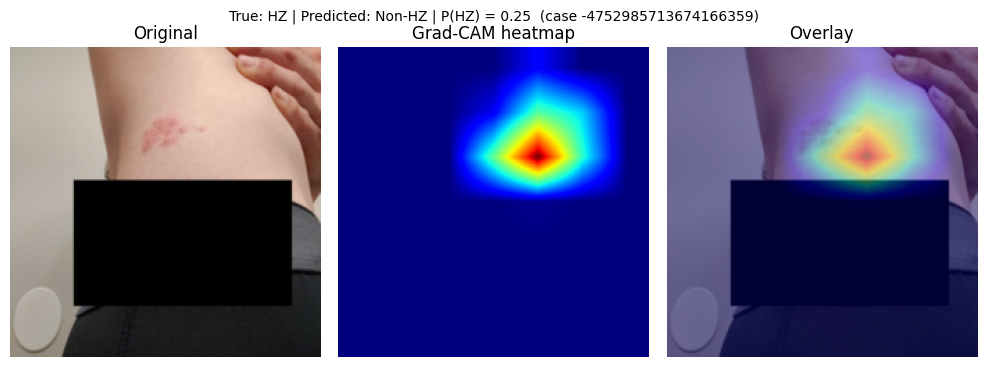

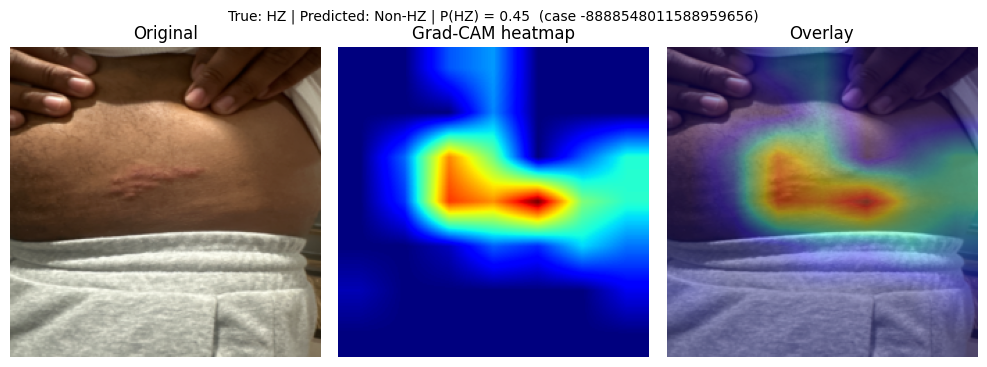

[incorrect_hz] saved 2 example(s) (2 available in the test set)


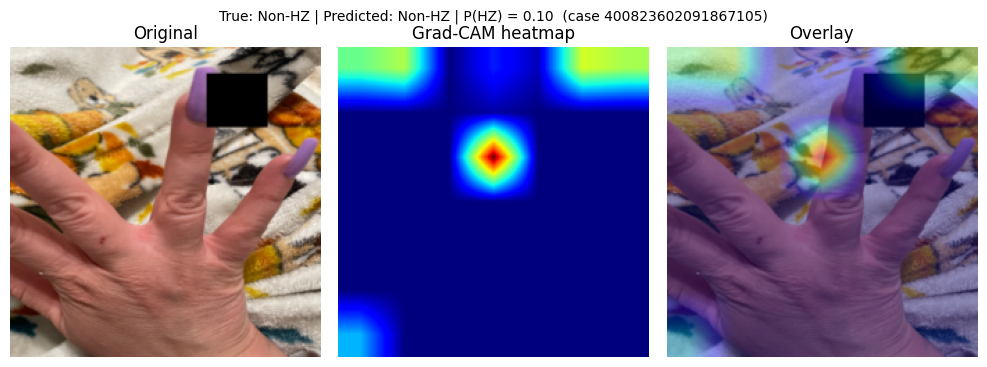

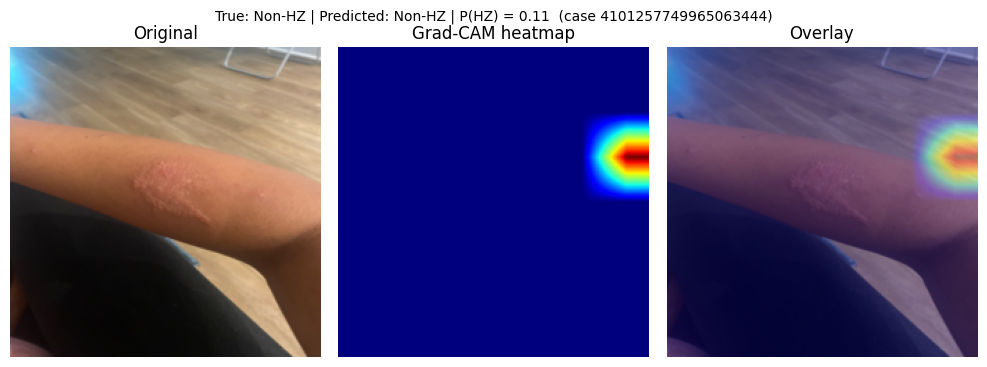

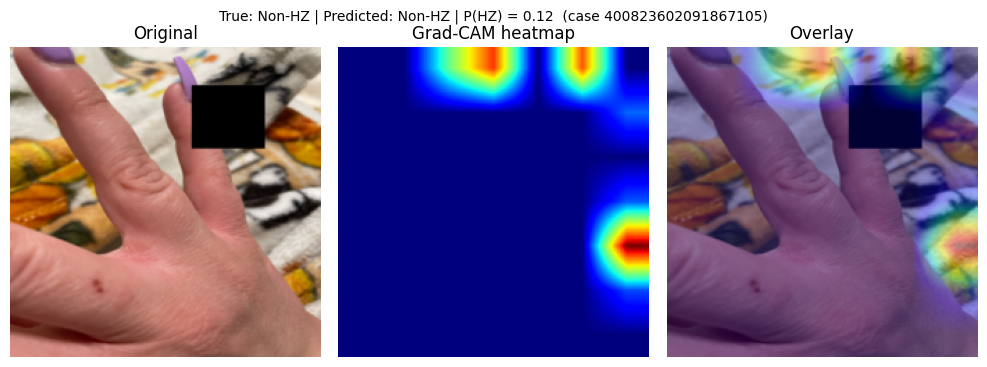

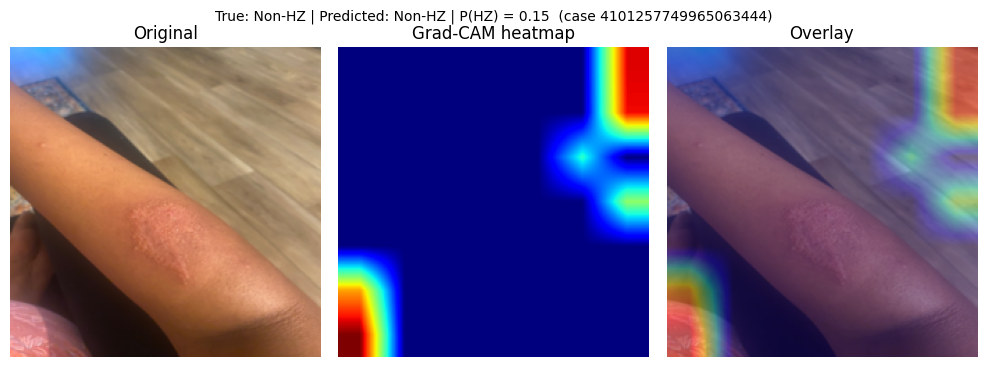

[correct_non_hz] saved 4 example(s) (11 available in the test set)


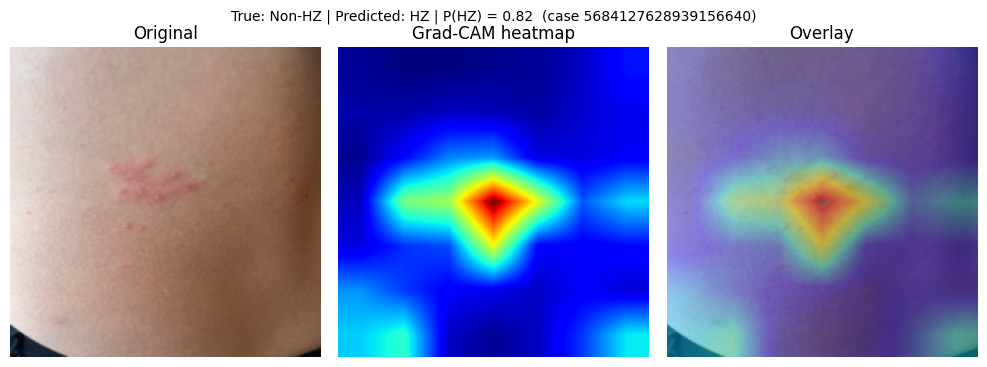

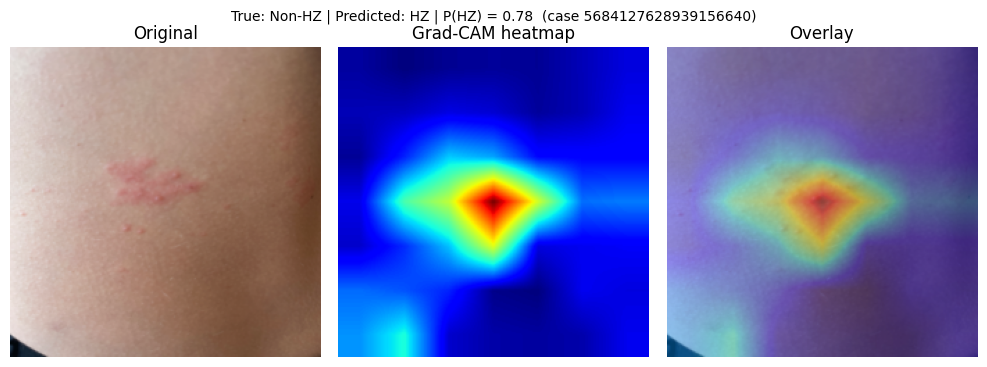

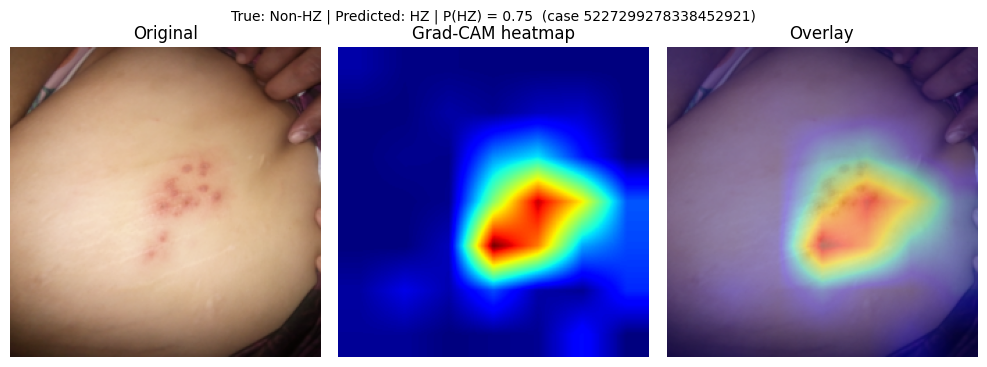

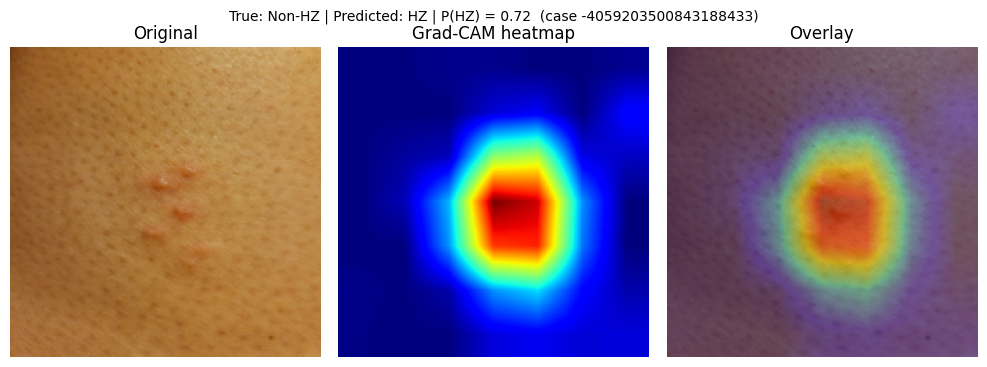

[incorrect_non_hz] saved 4 example(s) (8 available in the test set)


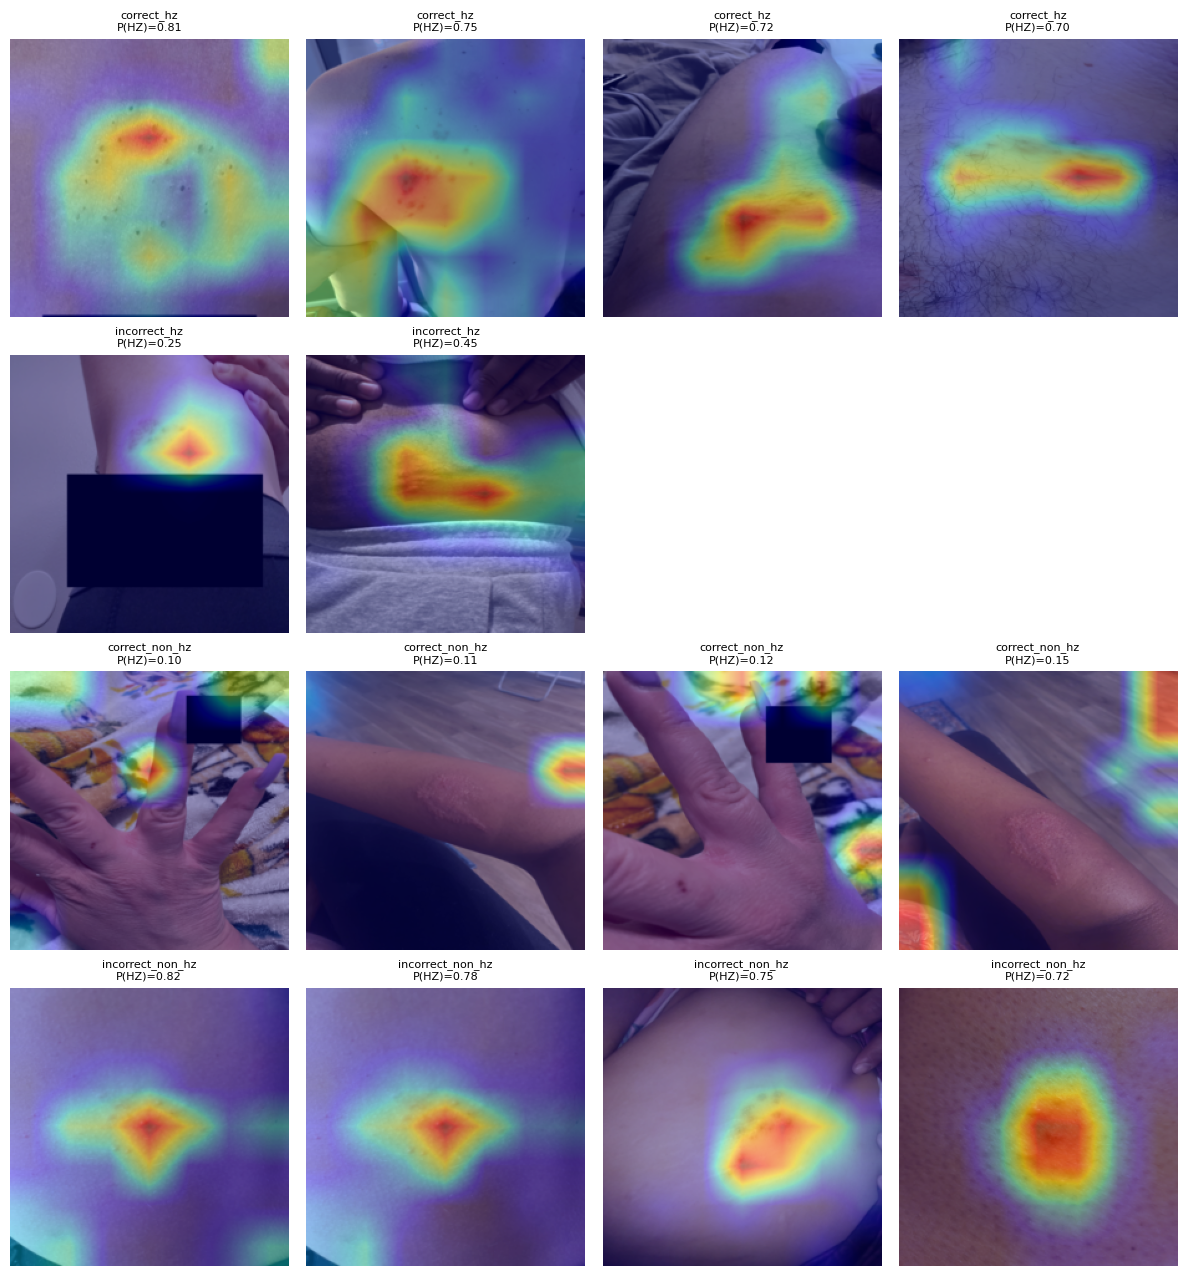

In [ ]:

model.load_state_dict(torch.load(CKPT, map_location=DEVICE))   # make sure the FINAL selected model is used
model.eval()

class GradCAM:
    def __init__(self, model, layer):
        self.model, self.acts, self.grads = model, None, None
        layer.register_forward_hook(self._fwd)
    def _fwd(self, m, i, o):
        self.acts = o.detach()
        if o.requires_grad: o.register_hook(lambda g: setattr(self, 'grads', g.detach()))
    def __call__(self, x):
        self.model.eval(); self.model.zero_grad()
        logit = self.model(x); logit.sum().backward()
        w = self.grads.mean(dim=(2, 3), keepdim=True)
        cam = torch.relu((w * self.acts).sum(1, keepdim=True))
        cam = nn.functional.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
        cam = cam[0, 0]; cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam.cpu().numpy(), torch.sigmoid(logit).item()

cam_engine = GradCAM(model, model.backbone.layer4[-1])

def denorm(x):
    return (x.cpu() * torch.tensor(STD)[:, None, None] + torch.tensor(MEAN)[:, None, None]).clamp(0, 1).permute(1, 2, 0).numpy()

CLS = {0: 'Non-HZ', 1: 'HZ'}
CATS = {  # name: (true label, predicted label)
    'correct_hz': (1, 1), 'incorrect_hz': (1, 0), 'correct_non_hz': (0, 0), 'incorrect_non_hz': (0, 1)}
N_PER_CAT = 4

gc = test_img.copy()                                         # TEST predictions only
gc['pred'] = (gc.prob >= 0.5).astype(int)
gc['conf'] = np.where(gc.pred == 1, gc.prob, 1 - gc.prob)
overview = {}
for cat, (t, p) in CATS.items():
    folder = f'{OUT}/gradcam/{cat}'; os.makedirs(folder, exist_ok=True)
    sub = gc[(gc.y == t) & (gc.pred == p)].sort_values('conf', ascending=False).head(N_PER_CAT)
    if sub.empty:
        msg = f'Category unavailable: no test images with true={CLS[t]}, predicted={CLS[p]}.'
        open(f'{folder}/UNAVAILABLE.txt', 'w').write(msg + '\n'); print(f'[{cat}] {msg}'); continue
    overview[cat] = []
    for rank, (_, r) in enumerate(sub.iterrows(), 1):
        x = eval_tf(Image.open(r.path).convert('RGB'))
        cam, _ = cam_engine(x.unsqueeze(0).to(DEVICE)); img = denorm(x)
        overview[cat].append((img, cam, r))
        fig, ax = plt.subplots(1, 3, figsize=(10, 3.7))
        ax[0].imshow(img); ax[0].set_title('Original')
        ax[1].imshow(cam, cmap='jet'); ax[1].set_title('Grad-CAM heatmap')
        ax[2].imshow(img); ax[2].imshow(cam, cmap='jet', alpha=0.4); ax[2].set_title('Overlay')
        for a in ax: a.axis('off')
        fig.suptitle(f'True: {CLS[int(r.y)]} | Predicted: {CLS[int(r.pred)]} | P(HZ) = {r.prob:.2f}  (case {r.case_id})', fontsize=10)
        plt.tight_layout(); plt.savefig(f'{folder}/{cat}_{rank}.png', dpi=150); plt.show()
    avail = int(((gc.y == t) & (gc.pred == p)).sum())
    print(f'[{cat}] saved {len(sub)} example(s) ({avail} available in the test set)')

# one overview figure: overlays, one row per available category
if overview:
    fig, ax = plt.subplots(len(overview), N_PER_CAT, figsize=(3 * N_PER_CAT, 3.2 * len(overview)), squeeze=False)
    for i, (cat, items) in enumerate(overview.items()):
        for j in range(N_PER_CAT):
            ax[i, j].axis('off')
            if j < len(items):
                img, cam, r = items[j]
                ax[i, j].imshow(img); ax[i, j].imshow(cam, cmap='jet', alpha=0.4)
                ax[i, j].set_title(f'{cat}\nP(HZ)={r.prob:.2f}', fontsize=8)
    plt.tight_layout(); plt.savefig(f'{OUT}/gradcam/gradcam_overview.png', dpi=150); plt.show()


## 14b. Final results file and summary

In [ ]:
KEYS = ['accuracy', 'precision', 'recall', 'specificity', 'f1', 'roc_auc']
n_cases = {s: int(data[s].case_id.nunique()) for s in data}
n_imgs  = {s: int(len(data[s])) for s in data}
best_epoch = int(best['epoch'])
final_results = {
    'model': 'Pretrained ResNet50 (ImageNet)', 'task': 'Binary HZ vs Non-HZ classification',
    'seed': SEED, 'decision_threshold': 0.5,
    'best_val_loss': float(best['val_loss']), 'best_epoch': best_epoch,
    'best_epoch_phase': int(history['phase'][best_epoch - 1]),
    'image_level': {k: results['test']['image_level'][k] for k in KEYS},   # TEST set
    'case_level':  {k: results['test']['case_level'][k] for k in KEYS},    # TEST set
    'confusion_counts_test': {'image_level': {k: results['test']['image_level'][k] for k in ['tn', 'fp', 'fn', 'tp']},
                              'case_level':  {k: results['test']['case_level'][k]  for k in ['tn', 'fp', 'fn', 'tp']}},
    'validation_image_level': {k: results['validation']['image_level'][k] for k in KEYS},
    'validation_case_level':  {k: results['validation']['case_level'][k]  for k in KEYS},
    'n_train_cases': n_cases['train'], 'n_validation_cases': n_cases['validation'], 'n_test_cases': n_cases['test'],
    'n_train_images': n_imgs['train'], 'n_validation_images': n_imgs['validation'], 'n_test_images': n_imgs['test'],
}
json.dump(final_results, open(f'{OUT}/final_results.json', 'w'), indent=2)

fmt = lambda d: ' | '.join(f'{k}={d[k]:.3f}' for k in KEYS)
print('=' * 70)
print('Model: Pretrained ResNet50 (ImageNet), fine-tuned' if FINE_TUNE else 'Model: Pretrained ResNet50 (ImageNet), frozen backbone')
print('Task : Binary HZ vs Non-HZ classification  (research / decision-support prototype, not a diagnosis)')
print(f"Training cases  : {n_cases['train']}   | Training images  : {n_imgs['train']}")
print(f"Validation cases: {n_cases['validation']}   | Validation images: {n_imgs['validation']}")
print(f"Test cases      : {n_cases['test']}   | Test images      : {n_imgs['test']}")
print(f"Seed: {SEED} | Best validation loss: {best['val_loss']:.4f} | Best epoch: {best_epoch} (phase {final_results['best_epoch_phase']})")
print('\nFinal TEST metrics, image-level:\n  ' + fmt(final_results['image_level']))
print('Final TEST metrics, case-level:\n  ' + fmt(final_results['case_level']))
print('=' * 70)
print(json.dumps(final_results, indent=2)[:300], '...')

Model: Pretrained ResNet50 (ImageNet), fine-tuned
Task : Binary HZ vs Non-HZ classification  (research / decision-support prototype, not a diagnosis)
Training cases  : 78   | Training images  : 155
Validation cases: 17   | Validation images: 35
Test cases      : 17   | Test images      : 33
Seed: 42 | Best validation loss: 0.5263 | Best epoch: 19 (phase 1)

Final TEST metrics, image-level:
  accuracy=0.697 | precision=0.600 | recall=0.857 | specificity=0.579 | f1=0.706 | roc_auc=0.692
Final TEST metrics, case-level:
  accuracy=0.588 | precision=0.545 | recall=0.750 | specificity=0.444 | f1=0.632 | roc_auc=0.639
{
  "model": "Pretrained ResNet50 (ImageNet)",
  "task": "Binary HZ vs Non-HZ classification",
  "seed": 42,
  "decision_threshold": 0.5,
  "best_val_loss": 0.5262822559901646,
  "best_epoch": 19,
  "best_epoch_phase": 1,
  "image_level": {
    "accuracy": 0.696969696969697,
    "precision": 0.6,
   ...


### Notes for the report
- Test set: 17 cases / 33 images, so metrics have wide uncertainty. Report image-level **and** case-level, and avoid strong claims.
- Model selection used validation loss only; the test set was evaluated once.
- Non-HZ negatives are hard negatives (HSV, impetigo, folliculitis, dermatitis, urticaria, insect bite), so the task is deliberately non-trivial.
- Framing: HZ detection / decision-support research prototype, not a clinical diagnosis.